In [111]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadaqeelkabir/top-github-repositories/github_top_repositories.csv


# 1. Title & Introduction

#  Top 1000 GitHub Repositories Analysis

##  Introduction
What makes a GitHub repository successful?  
In this project, we analyze the **Top 1000 GitHub repositories** to uncover patterns behind popularity, engagement, and programming trends.

---

##  Objectives
- Analyze stars and forks
- Identify top programming languages
- Understand what makes repositories popular
- Extract actionable insights

---

💡 If you find this useful, please upvote 👍

# 2 Import Libraries

In [112]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

# Settings for better visualization
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# 3 Load the Dataset

In [113]:
file_path = "/kaggle/input/datasets/muhammadaqeelkabir/top-github-repositories/github_top_repositories.csv"

# Correct way to read the CSV
df = pd.read_csv(file_path)

# 3️ Explore the Dataset

In [114]:
# Show the first 5 rows
df.head()

,Domain,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,Has Pages,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
0,Machine Learning,tensorflow,tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,194126,75247,194126,3715,False,False,True,1288956,2015-11-07T01:19:20Z,2026-03-14T00:28:29Z,2026-03-14T01:48:00Z,master,tensorflow,Organization,Apache License 2.0,"deep-learning, deep-neural-networks, distribut..."
1,Machine Learning,transformers,huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,157772,32464,157772,2282,True,False,True,453964,2018-10-29T13:56:00Z,2026-03-14T01:38:18Z,2026-03-13T23:15:04Z,main,huggingface,Organization,Apache License 2.0,"audio, deep-learning, deepseek, gemma, glm, ha..."
2,Machine Learning,prompts.chat,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",HTML,152186,19999,152186,28,True,True,True,231182,2022-12-05T13:54:13Z,2026-03-14T02:08:32Z,2026-03-13T14:06:54Z,main,f,User,Creative Commons Zero v1.0 Universal,"ai, artificial-intelligence, awesome-list, cha..."
3,Machine Learning,pytorch,pytorch/pytorch,Tensors and Dynamic neural networks in Python ...,Python,98216,27194,98216,18055,True,False,True,1273608,2016-08-13T05:26:41Z,2026-03-14T01:40:49Z,2026-03-14T02:08:49Z,main,pytorch,Organization,Other,"autograd, deep-learning, gpu, machine-learning..."
4,Machine Learning,LLMs-from-scratch,rasbt/LLMs-from-scratch,Implement a ChatGPT-like LLM in PyTorch from s...,Jupyter Notebook,87955,13422,87955,1,False,False,False,15703,2023-07-23T18:15:57Z,2026-03-14T02:06:45Z,2026-03-07T23:05:50Z,main,rasbt,User,Other,"ai, artificial-intelligence, chatbot, chatgpt,..."


In [115]:
# Last five row 
df.tail()

,Domain,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,Has Pages,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
2995,DevOps,websoft9,Websoft9/websoft9,Applications self-hosting and DevOps platform ...,Python,2086,318,2086,56,True,True,True,70233,2020-12-18T01:29:26Z,2026-03-10T10:47:47Z,2026-02-12T01:16:49Z,main,Websoft9,Organization,Other,"appstore, cicd, cloud-native, cockpit-project,..."
2996,DevOps,nodepass,NodePassProject/nodepass,"A secure, efficient TCP/UDP tunneling solution...",Go,2082,229,2082,0,False,False,False,2566,2024-12-19T08:26:03Z,2026-03-13T17:57:47Z,2026-03-09T15:21:00Z,main,NodePassProject,Organization,"BSD 3-Clause ""New"" or ""Revised"" License","api-rest, connection-pooling, cybersecurity, d..."
2997,DevOps,loonflow,blackholll/loonflow,A Intelligent and Visual Process Automation Sy...,TypeScript,2047,705,2047,13,True,False,True,65660,2018-02-08T06:26:53Z,2026-03-04T11:37:44Z,2026-03-14T00:52:09Z,master,blackholll,User,GNU Affero General Public License v3.0,"devops, django, python, ticket, workflow, work..."
2998,DevOps,terraboard,camptocamp/terraboard,:earth_africa: :clipboard: A web dashboard to...,Go,2002,167,2002,13,True,True,True,11638,2017-07-19T08:31:38Z,2026-03-11T12:51:22Z,2026-03-08T03:33:57Z,master,camptocamp,Organization,Apache License 2.0,"aws, devops, devops-tools, diff, go, infrastru..."
2999,DevOps,runme,runmedev/runme,DevOps Notebooks Built with Markdown,Go,2000,84,2000,149,True,False,True,101987,2022-07-18T07:58:54Z,2026-03-11T05:42:03Z,2026-03-13T17:34:30Z,main,runmedev,Organization,Apache License 2.0,"cloud, devops, markdown, notebooks, workflows"


In [116]:
# Random 5 rows
df.sample(5)

,Domain,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,Has Pages,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
1925,Web Development,awesome-pycharm,JetBrains/awesome-pycharm,A curated list of resources for learning and u...,NaN,312,48,312,4,False,False,False,41,2017-08-22T15:11:20Z,2026-03-09T23:02:10Z,2022-03-09T13:34:10Z,master,JetBrains,Organization,Apache License 2.0,"awesome, ide, pycharm, python, web-development"
2493,Blockchain,Java-Interview-Tutorial,Java-Edge/Java-Interview-Tutorial,请star，勿fork，因为爱force push！涵盖国际大厂Java/数据库/DDD/设...,Shell,2860,498,2860,0,True,False,True,59230,2019-07-22T16:33:34Z,2026-03-13T06:16:04Z,2026-03-13T06:16:01Z,main,Java-Edge,User,Apache License 2.0,"architecture, blockchain, ddd, java"
2922,DevOps,roadmaps,WeMakeDevs/roadmaps,This repository contains the list of communiti...,NaN,4080,1168,4080,41,True,False,True,477,2022-07-17T17:49:36Z,2026-03-12T17:58:00Z,2023-10-25T19:07:07Z,main,WeMakeDevs,Organization,MIT License,"backend, community, devops, devrel, frontend, ..."
1838,Web Development,translated-content,mdn/translated-content,7 community-maintained translations of MDN Web...,Markdown,1968,8331,1968,341,False,False,True,668136,2020-12-08T19:38:24Z,2026-03-13T08:53:59Z,2026-03-14T01:36:48Z,main,mdn,Organization,Other,"documentation, l10n, localization, mdn, web-de..."
1231,Go,build-web-application-with-golang,astaxie/build-web-application-with-golang,A golang ebook intro how to build a web with g...,Go,44155,10539,44155,137,True,False,True,38293,2012-08-02T11:49:35Z,2026-03-11T15:55:13Z,2024-05-12T00:47:46Z,master,astaxie,User,"BSD 3-Clause ""New"" or ""Revised"" License",NaN


In [117]:
# Dataset info: columns, types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Domain             3000 non-null   object
 1   Repository Name    3000 non-null   object
 2   Full Name          3000 non-null   object
 3   Description        2994 non-null   object
 4   Primary Language   2746 non-null   object
 5   Stars Count        3000 non-null   int64 
 6   Forks Count        3000 non-null   int64 
 7   Watchers Count     3000 non-null   int64 
 8   Open Issues Count  3000 non-null   int64 
 9   Has Wiki           3000 non-null   bool  
 10  Has Pages          3000 non-null   bool  
 11  Has Projects       3000 non-null   bool  
 12  Size (KB)          3000 non-null   int64 
 13  Created At         3000 non-null   object
 14  Updated At         3000 non-null   object
 15  Pushed At          3000 non-null   object
 16  Default Branch     3000 non-null   object


In [118]:
# Summary statistics for numerical columns
df.describe()

,Stars Count,Forks Count,Watchers Count,Open Issues Count,Size (KB)
count,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03
mean,20783.222667,3325.095667,20783.222667,398.147000,2.959861e+05
std,25860.464547,5538.962493,25860.464547,1065.464885,1.684439e+06
min,109.000000,4.000000,109.000000,0.000000,2.000000e+00
25%,6359.250000,677.000000,6359.250000,20.000000,7.420750e+03
50%,14231.000000,1755.000000,14231.000000,109.500000,3.832000e+04
75%,25784.000000,3754.000000,25784.000000,381.250000,1.598460e+05
max,409518.000000,75247.000000,409518.000000,18055.000000,6.183846e+07


In [119]:
 # summary for string/categorical columns
df.describe(include='object')

,Domain,Repository Name,Full Name,Description,Primary Language,Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
count,3000,3000,3000,2994,2746,3000,3000,3000,3000,3000,3000,2691,2793
unique,15,2526,2562,2554,54,2562,2511,2556,69,2185,2,21,2353
top,Machine Learning,cli,donnemartin/data-science-ipython-notebooks,Machine Learning From Scratch. Bare bones NumP...,Python,2015-01-23T19:38:29Z,2026-03-14T00:42:14Z,2026-03-09T06:21:50Z,master,microsoft,Organization,MIT License,blockchain
freq,200,7,4,4,605,4,8,4,1586,41,1885,898,6


In [120]:
print("Shape:", df.shape)

Shape: (3000, 21)


# 4. Data Cleaning

In [121]:
# Count missing values per column
df.isnull().sum()

Domain                 0
Repository Name        0
Full Name              0
Description            6
Primary Language     254
Stars Count            0
Forks Count            0
Watchers Count         0
Open Issues Count      0
Has Wiki               0
Has Pages              0
Has Projects           0
Size (KB)              0
Created At             0
Updated At             0
Pushed At              0
Default Branch         0
Owner Login            0
Owner Type             0
License              309
Topics               207
dtype: int64

In [122]:
df = df.dropna()

# 5️ Domain Analysis

In [123]:
# Number of Repositories per Domain
domain_counts = df['Domain'].value_counts()
print(domain_counts)

Domain
Go                  183
Rust                178
Android             176
iOS                 175
DevOps              163
C++                 160
Deep Learning       159
Blockchain          157
Machine Learning    155
Data Science        150
Java                148
Python              147
Cybersecurity       136
Web Development     131
JavaScript          124
Name: count, dtype: int64


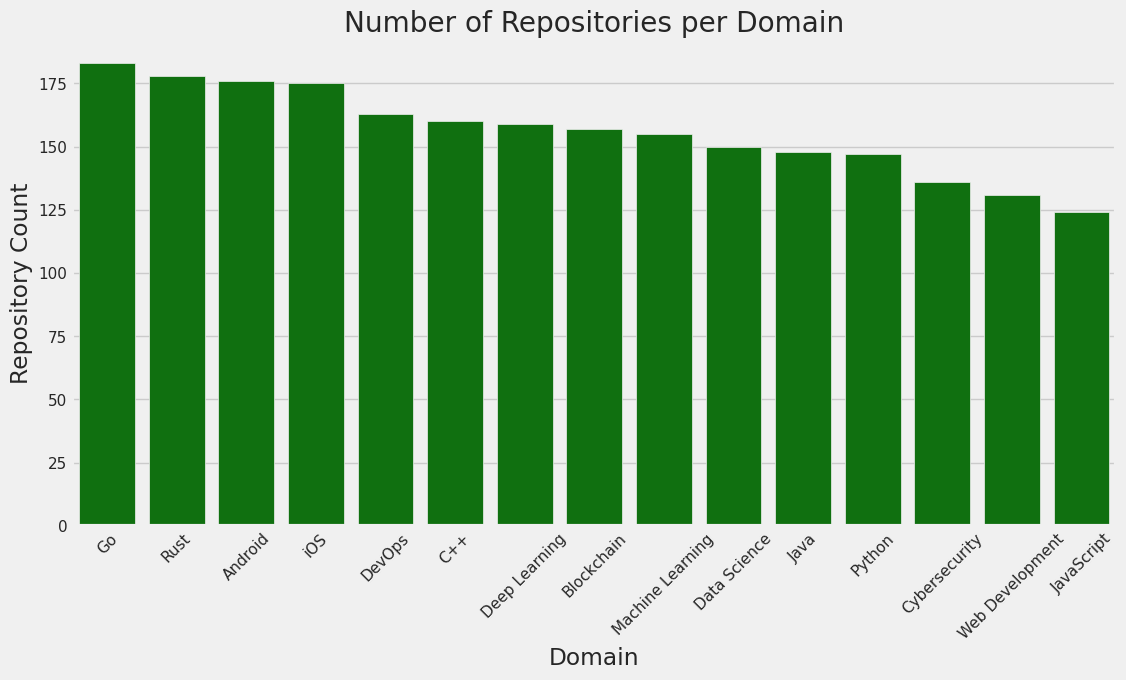

In [124]:
plt.figure(figsize=(12,6))
sns.barplot(x=domain_counts.index, y=domain_counts.values, color="green")
plt.xticks(rotation=45)
plt.title("Number of Repositories per Domain")
plt.ylabel("Repository Count")
plt.show()

In [125]:
# Most Popular Domain by Stars
domain_stars = df.groupby('Domain')['Stars Count'].sum().sort_values(ascending=False)
print(domain_stars)

Domain
Python              8981365
Go                  6107143
Rust                4644729
Machine Learning    4446139
C++                 4429451
Deep Learning       4104136
Android             3954991
JavaScript          3014478
iOS                 2792170
Java                2672168
Data Science        1848496
DevOps              1520499
Blockchain           978332
Cybersecurity        679289
Web Development      304078
Name: Stars Count, dtype: int64


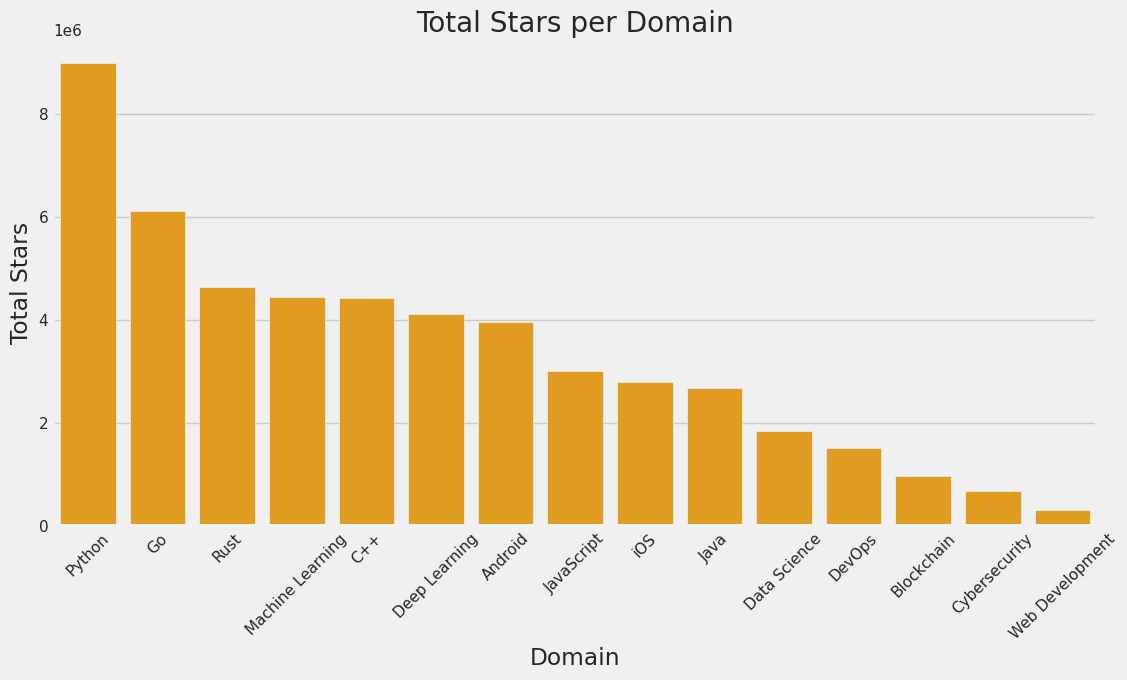

In [126]:
plt.figure(figsize=(12,6))
sns.barplot(x=domain_stars.index, y=domain_stars.values, color="orange")
plt.xticks(rotation=45)
plt.title("Total Stars per Domain")
plt.ylabel("Total Stars")
plt.show()

# 6️ Repository Popularity Analysis

In [127]:
# Top 10 Repositories by Stars
top_starred = df[['Full Name','Stars Count','Domain','Primary Language']].sort_values(by='Stars Count', ascending=False).head(10)
top_starred

,Full Name,Stars Count,Domain,Primary Language
400,public-apis/public-apis,409518,Python,Python
401,EbookFoundation/free-programming-books,383962,Python,Python
402,donnemartin/system-design-primer,338749,Python,Python
403,vinta/awesome-python,286998,Python,Python
404,TheAlgorithms/Python,218590,Python,Python
0,tensorflow/tensorflow,194126,Machine Learning,C++
200,tensorflow/tensorflow,194126,Deep Learning,C++
1000,tensorflow/tensorflow,194126,C++,C++
2200,flutter/flutter,175549,iOS,Dart
2000,flutter/flutter,175549,Android,Dart


In [128]:
# Top 10 Repositories by Forks
top_forks = df[['Full Name','Forks Count','Domain','Primary Language']].sort_values(by='Forks Count', ascending=False).head(10)
top_forks

,Full Name,Forks Count,Domain,Primary Language
0,tensorflow/tensorflow,75247,Machine Learning,C++
200,tensorflow/tensorflow,75246,Deep Learning,C++
1000,tensorflow/tensorflow,75246,C++,C++
401,EbookFoundation/free-programming-books,66010,Python,Python
205,opencv/opencv,56553,Deep Learning,C++
1007,opencv/opencv,56553,C++,C++
402,donnemartin/system-design-primer,54874,Python,Python
404,TheAlgorithms/Python,50173,Python,Python
400,public-apis/public-apis,44245,Python,Python
1203,kubernetes/kubernetes,42674,Go,Go


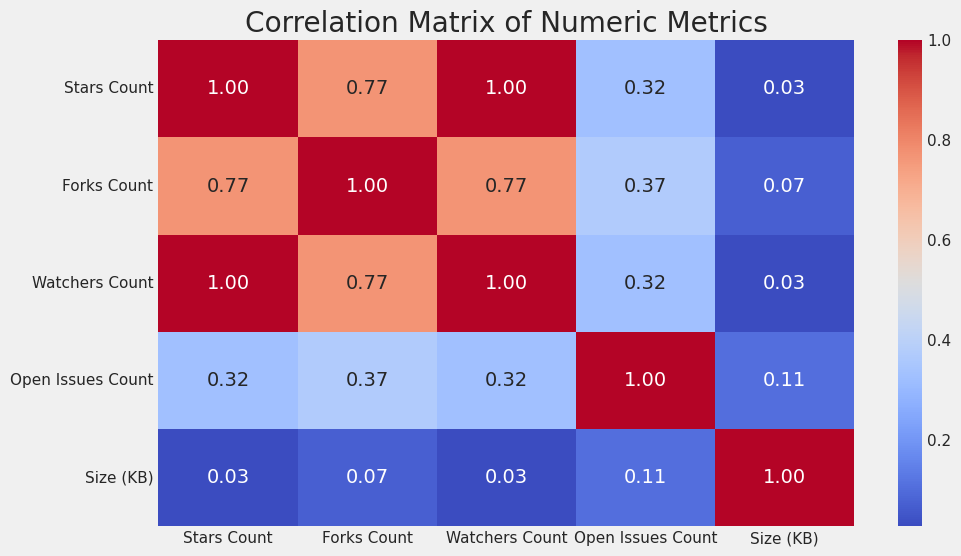

In [129]:
# Correlation Between Engagement Metrics
numeric_cols = ['Stars Count','Forks Count','Watchers Count','Open Issues Count','Size (KB)']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Metrics")
plt.show()

# 7️ Programming Language Analysis

In [130]:
# Top 10 primary languages used
top_languages = df['Primary Language'].value_counts().head(10)
print(top_languages)

Primary Language
Python              530
Go                  327
C++                 250
Rust                242
Java                228
JavaScript          218
TypeScript          121
Jupyter Notebook     95
Swift                54
HTML                 40
Name: count, dtype: int64


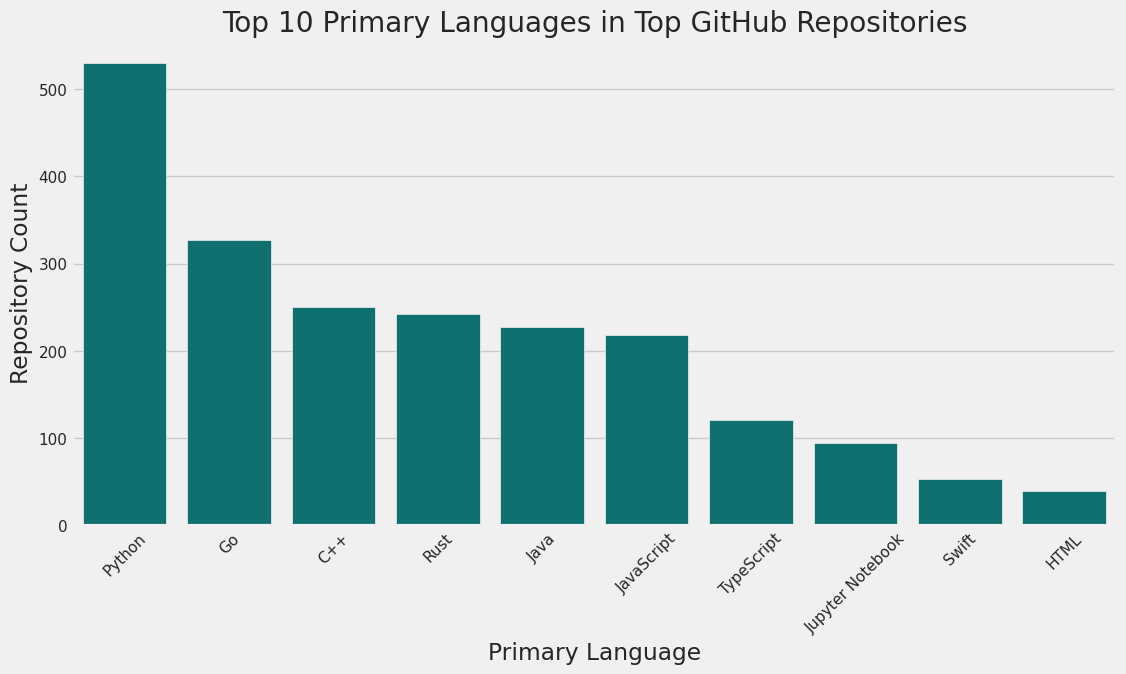

In [131]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_languages.index, y=top_languages.values, color="teal")
plt.xticks(rotation=45)
plt.title("Top 10 Primary Languages in Top GitHub Repositories")
plt.ylabel("Repository Count")
plt.show()

# 8️ Owner Type Analysis

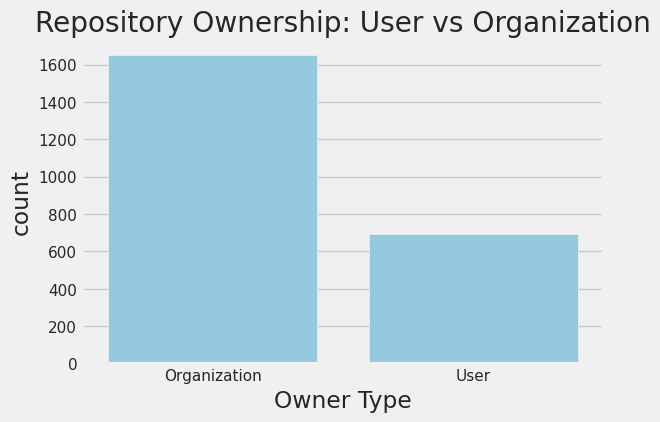

In [132]:
plt.figure(figsize=(6,4))
sns.countplot(x='Owner Type', data=df, color="skyblue")  # single color
plt.title("Repository Ownership: User vs Organization")
plt.show()

# 9️ Time-Based Analysis

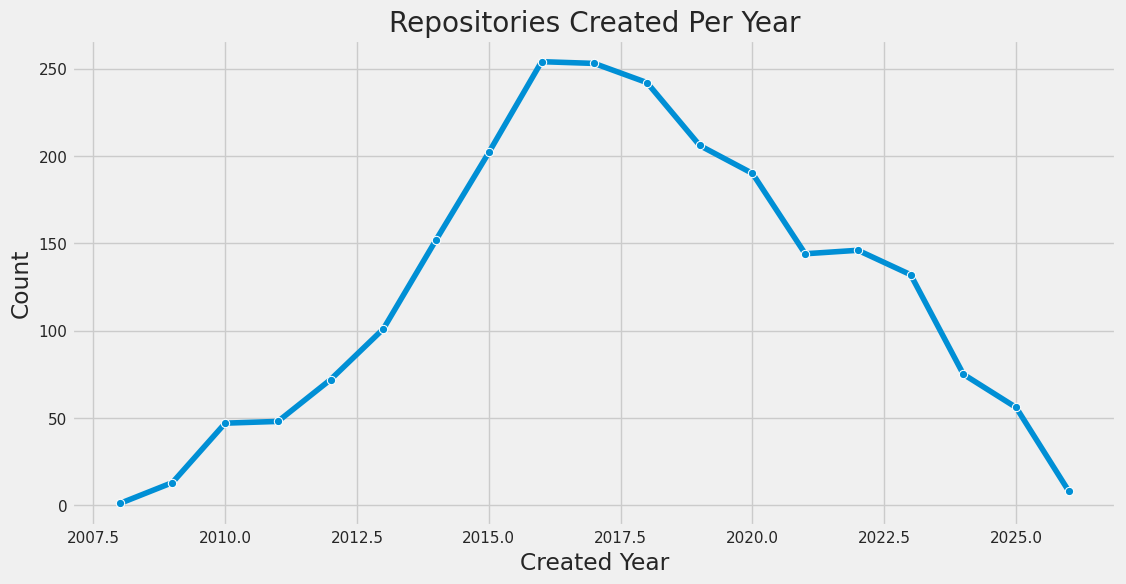

In [133]:
# Convert date columns to datetime
df['Created At'] = pd.to_datetime(df['Created At'])
df['Updated At'] = pd.to_datetime(df['Updated At'])
df['Pushed At'] = pd.to_datetime(df['Pushed At'])

# Repositories created per year
df['Created Year'] = df['Created At'].dt.year
created_year_counts = df['Created Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=created_year_counts.index, y=created_year_counts.values, marker="o")
plt.title("Repositories Created Per Year")
plt.ylabel("Count")
plt.show()

In [134]:
# Topics & Description Analysis
from collections import Counter

all_topics = df['Topics'].dropna().apply(lambda x: x.split(','))
flat_topics = [topic.strip() for sublist in all_topics for topic in sublist]
top_topics = Counter(flat_topics).most_common(20)

# Display
pd.DataFrame(top_topics, columns=['Topic','Count'])

,Topic,Count
0,python,405
1,machine-learning,402
2,deep-learning,349
3,android,336
4,ios,258
5,hacktoberfest,250
6,data-science,224
7,devops,185
8,rust,181
9,blockchain,170


In [135]:
# Save with new computed columns
df.to_csv("github_top_repositories_cleaned.csv", index=False)

##  Conclusion

This analysis shows that successful GitHub repositories are driven by:
- Strong community engagement
- Popular programming ecosystems
- High usability and real-world value

---

🚀 Success on GitHub is not just about code —  
it’s about **impact, usability, and community**.

---

⭐ If you like this notebook, please upvote!